# 미세먼지 공공데이터 분석
## Open API 데이터 수집 → 전처리 → 분석 → 시각화 

---

## 학습 목표

| 단계| 내용 | 핵심 키워드 |
|------|------|-------------|
| ️1 | **Open API** 개념 이해 및 데이터 수집 | `requests`, `URL`, `API Key` |
| ️2 | **JSON** 구조 이해 및 DataFrame 변환 | `json()`, `pd.DataFrame()` |
| ️3 | CSV 저장 & 불러오기 | `to_csv()`, `read_csv()` |
| ️4 | **날짜 전처리** — 문자열 → datetime | `to_datetime()`, `dt.year` |
| ️5 | 데이터 필터링 | 불리언 인덱싱, `reset_index()` |
|️ 6 | **groupby** 집계 분석 | `groupby()`, `agg()` |
|️ 7 | 최대·최소값 탐색 | `idxmax()`, `argmax()` |
| ️8 | **시각화** | `plot()`, `sns.barplot()` |
|
>  **데이터 출처**: 한국환경공단 에어코리아 미세먼지경보 발령현황
> ([공공데이터포털](https://www.data.go.kr/data/15073885/openapi.do))


<br>

---
# PART 1 — 라이브러리 불러오기 & 환경 설정

────────────────────────────────────────────────────────────


## 1-1. 필요한 라이브러리 설치


| 라이브러리 | 용도 |
|------------|------|
| `requests` | 인터넷(Open API)에서 데이터 받아오기 |


In [1]:
!pip install requests

## 1-2. 라이브러리 불러오기 & 기본 설정

- `plt.rc('font', family='Malgun Gothic')` — 그래프에서 **한글**이 제대로 표시되도록 설정
- `plt.rc('axes', unicode_minus=False)` — 그래프 축의 **음수 기호(−)** 깨짐 방지
- `pd.options.display.float_format` — 소수점 이하 **1자리**로 표시


In [31]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import requests

In [32]:
plt.rc('font', family='Malgun Gothic')
plt.rc('axes', unicode_minus=False)

In [33]:
# 소수점 이하 1자리로 표시
pd.options.display.float_format = '{:.1f}'.format

<br>

---
# PART 2 — Open API 이해 및 데이터 수집

────────────────────────────────────────────────────────────


## 2-1. Open API란 무엇인가요?

```
우리 ──── 요청(Request) ────▶ 서버(공공데이터포털)
     ◀─── 응답(Response) ────
```

- **API** (Application Programming Interface) : 프로그램끼리 대화하는 창구
- **Open API** : 누구나 키(API Key)를 발급받아 사용할 수 있는 공개 API
- 우리는 **URL 주소**로 요청을 보내고, **JSON 형식**으로 데이터를 받습니다.

### API Key 발급 방법
1. [공공데이터포털](https://www.data.go.kr) 회원가입
2. `한국환경공단_에어코리아_미세먼지경보발령현황` 검색
> https://www.data.go.kr/data/15073885/openapi.do 
3. **활용 신청** → 승인 후 **서비스키** 발급

> 아래 예시에서는 샘플 키를 사용합니다. 실제 실습에서는 본인 키를 사용하세요!

## 2-2 데이터 요청하기 — `requests.get()`

| 코드 | 의미 |
|------|------|
| `requests.get(url)` | URL로 데이터 요청 → **Response 객체** 반환 |
| `requests.get(url).text` | 응답 내용을 **문자열(str)** 로 반환 |
| `requests.get(url).json()` | 응답 JSON 문자열을 **파이썬 딕셔너리** 로 변환 |

>  `<Response [200]>` — 숫자 200은 **요청 성공**을 의미합니다.         
> `400`, `401`, `500` 등이 나오면 url 또는 API Key를 확인하세요.


In [40]:
url = 'http://apis.data.go.kr/B552584/UlfptcaAlarmInqireSvc/getUlfptcaAlarmInfo?year=2020&pageNo=1&numOfRows=1000&returnType=json&serviceKey=E2%2FntezPtGt%2Be6hcf0qQzS1wPiFRDcPOQ%2BQCLmaR0jS28VIQPy%2F8destnqAxbUXjKWPGw63G1Rw2sIp7FTLfeg%3D%3D'

In [41]:
requests.get(url)

<Response [200]>

In [42]:
requests.get(url).json()

{'response': {'body': {'totalCount': 304,
   'items': [{'clearVal': '33',
     'sn': '323',
     'districtName': '충북',
     'dataDate': '2020-12-29',
     'issueVal': '77',
     'issueTime': '13:00',
     'clearDate': '2020-12-29',
     'issueDate': '2020-12-29',
     'moveName': '중부권역',
     'clearTime': '19:00',
     'issueGbn': '주의보',
     'itemCode': 'PM25'},
    {'clearVal': '33',
     'sn': '322',
     'districtName': '세종',
     'dataDate': '2020-12-29',
     'issueVal': '80',
     'issueTime': '12:00',
     'clearDate': '2020-12-29',
     'issueDate': '2020-12-29',
     'moveName': '세종권역',
     'clearTime': '19:00',
     'issueGbn': '주의보',
     'itemCode': 'PM25'},
    {'clearVal': '34',
     'sn': '320',
     'districtName': '대구',
     'dataDate': '2020-12-28',
     'issueVal': '83',
     'issueTime': '14:00',
     'clearDate': '2020-12-28',
     'issueDate': '2020-12-28',
     'moveName': '대구권역',
     'clearTime': '16:00',
     'issueGbn': '주의보',
     'itemCode': 'PM25'},
    

## 2-3. JSON이란 무엇인가요?

```json
{
  "키1": "값1",
  "키2": 123,
  "키3": ["리스트", "도", "가능"]
}
```

- **JSON** (JavaScript Object Notation) : 인터넷에서 데이터를 주고받는 표준 형식
- 파이썬의 **딕셔너리 `{}`** 와 구조가 같아요!
- `requests.get(url).json()` 으로 **바로 딕셔너리**로 변환할 수 있습니다.


In [43]:
data = requests.get(url).json()
data

{'response': {'body': {'totalCount': 304,
   'items': [{'clearVal': '33',
     'sn': '323',
     'districtName': '충북',
     'dataDate': '2020-12-29',
     'issueVal': '77',
     'issueTime': '13:00',
     'clearDate': '2020-12-29',
     'issueDate': '2020-12-29',
     'moveName': '중부권역',
     'clearTime': '19:00',
     'issueGbn': '주의보',
     'itemCode': 'PM25'},
    {'clearVal': '33',
     'sn': '322',
     'districtName': '세종',
     'dataDate': '2020-12-29',
     'issueVal': '80',
     'issueTime': '12:00',
     'clearDate': '2020-12-29',
     'issueDate': '2020-12-29',
     'moveName': '세종권역',
     'clearTime': '19:00',
     'issueGbn': '주의보',
     'itemCode': 'PM25'},
    {'clearVal': '34',
     'sn': '320',
     'districtName': '대구',
     'dataDate': '2020-12-28',
     'issueVal': '83',
     'issueTime': '14:00',
     'clearDate': '2020-12-28',
     'issueDate': '2020-12-28',
     'moveName': '대구권역',
     'clearTime': '16:00',
     'issueGbn': '주의보',
     'itemCode': 'PM25'},
    

## 2-4. 딕셔너리 구조 탐색하기

받아온 데이터 구조를 한 단계씩 파고들어 봅니다.

```
data
 └─ 'response'
      └─ 'body'
           └─ 'items'   ← 우리가 원하는 실제 데이터 목록!
                └─ [ {row1}, {row2}, ... ]   ← 딕셔너리들의 리스트
```

In [44]:
data['response']['body']['items']

[{'clearVal': '33',
  'sn': '323',
  'districtName': '충북',
  'dataDate': '2020-12-29',
  'issueVal': '77',
  'issueTime': '13:00',
  'clearDate': '2020-12-29',
  'issueDate': '2020-12-29',
  'moveName': '중부권역',
  'clearTime': '19:00',
  'issueGbn': '주의보',
  'itemCode': 'PM25'},
 {'clearVal': '33',
  'sn': '322',
  'districtName': '세종',
  'dataDate': '2020-12-29',
  'issueVal': '80',
  'issueTime': '12:00',
  'clearDate': '2020-12-29',
  'issueDate': '2020-12-29',
  'moveName': '세종권역',
  'clearTime': '19:00',
  'issueGbn': '주의보',
  'itemCode': 'PM25'},
 {'clearVal': '34',
  'sn': '320',
  'districtName': '대구',
  'dataDate': '2020-12-28',
  'issueVal': '83',
  'issueTime': '14:00',
  'clearDate': '2020-12-28',
  'issueDate': '2020-12-28',
  'moveName': '대구권역',
  'clearTime': '16:00',
  'issueGbn': '주의보',
  'itemCode': 'PM25'},
 {'clearVal': '28',
  'sn': '321',
  'districtName': '충남',
  'dataDate': '2020-12-28',
  'issueVal': '76',
  'issueTime': '21:00',
  'clearDate': '2020-12-29',
  '

## 2-5. 리스트 → DataFrame 변환 & csv 저장

딕셔너리들의 리스트 → `pd.DataFrame()` 으로 **DataFrame**  만들 수 있어요!

```python
pd.DataFrame( [딕셔너리, 딕셔너리, ...] )

In [45]:
df = pd.DataFrame(data['response']['body']['items'])
df

,clearVal,sn,districtName,dataDate,issueVal,issueTime,clearDate,issueDate,moveName,clearTime,issueGbn,itemCode
0,33,323,충북,2020-12-29,77,13:00,2020-12-29,2020-12-29,중부권역,19:00,주의보,PM25
1,33,322,세종,2020-12-29,80,12:00,2020-12-29,2020-12-29,세종권역,19:00,주의보,PM25
2,34,320,대구,2020-12-28,83,14:00,2020-12-28,2020-12-28,대구권역,16:00,주의보,PM25
3,28,321,충남,2020-12-28,76,21:00,2020-12-29,2020-12-28,북부권역,22:00,주의보,PM25
4,26,318,대구,2020-12-24,80,11:00,2020-12-24,2020-12-24,대구권역,15:00,주의보,PM25
...,...,...,...,...,...,...,...,...,...,...,...,...
299,33,4,충북,2020-01-03,76,12:00,2020-01-05,2020-01-03,중부권역,16:00,주의보,PM25
300,31,3,충남,2020-01-03,85,11:00,2020-01-05,2020-01-03,북부권역,15:00,주의보,PM25
301,19,1,전북,2020-01-03,80,02:00,2020-01-05,2020-01-03,익산권역,15:00,주의보,PM25
302,33,2,경기,2020-01-03,82,11:00,2020-01-04,2020-01-03,남부권,17:00,주의보,PM25


In [46]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 304 entries, 0 to 303
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   clearVal      304 non-null    object
 1   sn            304 non-null    object
 2   districtName  304 non-null    object
 3   dataDate      304 non-null    object
 4   issueVal      304 non-null    object
 5   issueTime     304 non-null    object
 6   clearDate     304 non-null    object
 7   issueDate     304 non-null    object
 8   moveName      304 non-null    object
 9   clearTime     304 non-null    object
 10  issueGbn      304 non-null    object
 11  itemCode      304 non-null    object
dtypes: object(12)
memory usage: 28.6+ KB


## 2-6. csv 파일로 저장하기

- `to_csv('파일명.csv', index=False)` — DataFrame을 CSV 파일로 저장
- `index=False` — 인덱스 번호(0, 1, 2...)를 파일의 새로운 Index 열로 만들지 않음
- 저장 후 `read_csv()`로 다시 불러오면 **파일 저장 확인** 가능!

In [47]:
df.to_csv('finedust_2020.csv',  index=False)

In [48]:
df = pd.read_csv('finedust_2020.csv')
df

,clearVal,sn,districtName,dataDate,issueVal,issueTime,clearDate,issueDate,moveName,clearTime,issueGbn,itemCode
0,33,323,충북,2020-12-29,77,13:00,2020-12-29,2020-12-29,중부권역,19:00,주의보,PM25
1,33,322,세종,2020-12-29,80,12:00,2020-12-29,2020-12-29,세종권역,19:00,주의보,PM25
2,34,320,대구,2020-12-28,83,14:00,2020-12-28,2020-12-28,대구권역,16:00,주의보,PM25
3,28,321,충남,2020-12-28,76,21:00,2020-12-29,2020-12-28,북부권역,22:00,주의보,PM25
4,26,318,대구,2020-12-24,80,11:00,2020-12-24,2020-12-24,대구권역,15:00,주의보,PM25
...,...,...,...,...,...,...,...,...,...,...,...,...
299,33,4,충북,2020-01-03,76,12:00,2020-01-05,2020-01-03,중부권역,16:00,주의보,PM25
300,31,3,충남,2020-01-03,85,11:00,2020-01-05,2020-01-03,북부권역,15:00,주의보,PM25
301,19,1,전북,2020-01-03,80,02:00,2020-01-05,2020-01-03,익산권역,15:00,주의보,PM25
302,33,2,경기,2020-01-03,82,11:00,2020-01-04,2020-01-03,남부권,17:00,주의보,PM25


In [49]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 304 entries, 0 to 303
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   clearVal      304 non-null    int64 
 1   sn            304 non-null    int64 
 2   districtName  304 non-null    object
 3   dataDate      304 non-null    object
 4   issueVal      304 non-null    int64 
 5   issueTime     304 non-null    object
 6   clearDate     304 non-null    object
 7   issueDate     304 non-null    object
 8   moveName      304 non-null    object
 9   clearTime     304 non-null    object
 10  issueGbn      304 non-null    object
 11  itemCode      304 non-null    object
dtypes: int64(3), object(9)
memory usage: 28.6+ KB




---
# PART 3 —  데이터 로드 및 기본 탐색 (EDA)

---


## 3-1. 데이터 불러오기

> **데이터 안내**
>
> - 파일명 : `finedust_2020.csv`
> - 출처 : 한국환경공단 에어코리아 미세먼지경보 발령현황
> - Part 2에서 API로 수집·저장한 파일을 분석합니다.
> - API 수집이 어려운 경우, 사캠 자료실 파일을 사용하세요.

### 주요 컬럼 설명

| 컬럼명 | 설명 |
|--------|------|
| `itemCode` | 미세먼지 종류 — `PM10`: 미세먼지, `PM25`: 초미세먼지 |
| `issueGbn` | 경보 단계 — `주의보` / `경보` |
| `issueDate` | 경보 발령 일시 |
| `issueVal` | 발령 당시 농도 (㎍/㎥) |
| `clearDate` | 경보 해제 일시 |
| `clearVal` | 해제 당시 농도 (㎍/㎥) |
| `districtName` | 발령 지역 (시·도) |
| `moveName` | 발령 권역 (세부 지역) |

> 전체 컬럼 설명: https://www.data.go.kr/data/15073885/openapi.do


In [50]:
df = pd.read_csv('finedust_2020.csv')
df

,clearVal,sn,districtName,dataDate,issueVal,issueTime,clearDate,issueDate,moveName,clearTime,issueGbn,itemCode
0,33,323,충북,2020-12-29,77,13:00,2020-12-29,2020-12-29,중부권역,19:00,주의보,PM25
1,33,322,세종,2020-12-29,80,12:00,2020-12-29,2020-12-29,세종권역,19:00,주의보,PM25
2,34,320,대구,2020-12-28,83,14:00,2020-12-28,2020-12-28,대구권역,16:00,주의보,PM25
3,28,321,충남,2020-12-28,76,21:00,2020-12-29,2020-12-28,북부권역,22:00,주의보,PM25
4,26,318,대구,2020-12-24,80,11:00,2020-12-24,2020-12-24,대구권역,15:00,주의보,PM25
...,...,...,...,...,...,...,...,...,...,...,...,...
299,33,4,충북,2020-01-03,76,12:00,2020-01-05,2020-01-03,중부권역,16:00,주의보,PM25
300,31,3,충남,2020-01-03,85,11:00,2020-01-05,2020-01-03,북부권역,15:00,주의보,PM25
301,19,1,전북,2020-01-03,80,02:00,2020-01-05,2020-01-03,익산권역,15:00,주의보,PM25
302,33,2,경기,2020-01-03,82,11:00,2020-01-04,2020-01-03,남부권,17:00,주의보,PM25


## 3-2. 데이터 구조 확인 — `info()`, `columns`, `iloc`

| 함수/속성 | 역할 |
|-----------|------|
| `df.info()` | 각 열의 이름, 데이터 타입, 결측치 수 한눈에 보기 |
| `df.columns` | 열 이름 목록 확인 |
| `df.iloc[0]` | 0번째 행(첫 번째 데이터) 자세히 보기 |
| `df.head(n)` | 처음 n행 미리보기 (기본 5행) |


In [52]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 304 entries, 0 to 303
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   clearVal      304 non-null    int64 
 1   sn            304 non-null    int64 
 2   districtName  304 non-null    object
 3   dataDate      304 non-null    object
 4   issueVal      304 non-null    int64 
 5   issueTime     304 non-null    object
 6   clearDate     304 non-null    object
 7   issueDate     304 non-null    object
 8   moveName      304 non-null    object
 9   clearTime     304 non-null    object
 10  issueGbn      304 non-null    object
 11  itemCode      304 non-null    object
dtypes: int64(3), object(9)
memory usage: 28.6+ KB


In [53]:
df.columns

Index(['clearVal', 'sn', 'districtName', 'dataDate', 'issueVal', 'issueTime',
       'clearDate', 'issueDate', 'moveName', 'clearTime', 'issueGbn',
       'itemCode'],
      dtype='object')

In [54]:
df.head()

,clearVal,sn,districtName,dataDate,issueVal,issueTime,clearDate,issueDate,moveName,clearTime,issueGbn,itemCode
0,33,323,충북,2020-12-29,77,13:00,2020-12-29,2020-12-29,중부권역,19:00,주의보,PM25
1,33,322,세종,2020-12-29,80,12:00,2020-12-29,2020-12-29,세종권역,19:00,주의보,PM25
2,34,320,대구,2020-12-28,83,14:00,2020-12-28,2020-12-28,대구권역,16:00,주의보,PM25
3,28,321,충남,2020-12-28,76,21:00,2020-12-29,2020-12-28,북부권역,22:00,주의보,PM25
4,26,318,대구,2020-12-24,80,11:00,2020-12-24,2020-12-24,대구권역,15:00,주의보,PM25


In [55]:
df.iloc[0]       # df.iloc[행번호] — 위치 기반 인덱싱 (0부터 시작)

clearVal                33
sn                     323
districtName            충북
dataDate        2020-12-29
issueVal                77
issueTime            13:00
clearDate       2020-12-29
issueDate       2020-12-29
moveName              중부권역
clearTime            19:00
issueGbn               주의보
itemCode              PM25
Name: 0, dtype: object

In [56]:
df.iloc[-1]

clearVal                34
sn                       5
districtName            전북
dataDate        2020-01-03
issueVal                81
issueTime            22:00
clearDate       2020-01-05
issueDate       2020-01-03
moveName              전주권역
clearTime            14:00
issueGbn               주의보
itemCode              PM25
Name: 303, dtype: object

<br>

---
# PART 4 — 날짜 데이터 전처리

────────────────────────────────────────────────────────────


## 4-1. 날짜 열 확인 — 왜 전처리가 필요할가요?

`df.info()` 결과를 보면 `issueDate` 가 **문자열(object, str)타입**

```
문자열 상태:  '2020-03-25'   →  연·월·일 추출 불가
datetime 상태: '2020-03-25'  →  연·월·일 추출 가능
```

>  **datetime** 형식으로 변환해야 `.dt.year`, `.dt.month`, `.dt.day` 로 날짜 정보를 뽑을 수 있어요!


In [57]:
df['issueDate']

0      2020-12-29
1      2020-12-29
2      2020-12-28
3      2020-12-28
4      2020-12-24
          ...    
299    2020-01-03
300    2020-01-03
301    2020-01-03
302    2020-01-03
303    2020-01-03
Name: issueDate, Length: 304, dtype: object

In [58]:
df['issueDate']

0      2020-12-29
1      2020-12-29
2      2020-12-28
3      2020-12-28
4      2020-12-24
          ...    
299    2020-01-03
300    2020-01-03
301    2020-01-03
302    2020-01-03
303    2020-01-03
Name: issueDate, Length: 304, dtype: object

## 4-2. 문자열 → datetime 변환 — `pd.to_datetime()`

```python
# 변환만 해서 결과 확인
pd.to_datetime(df['issueDate'])

# 변환 후 열에 저장(업데이트)
df['issueDate'] = pd.to_datetime(df['issueDate'])
```

> 변환 결과를 **다시 열에 저장(업데이트)** 잊지마세요!


In [59]:
pd.to_datetime(df['issueDate'])

0     2020-12-29
1     2020-12-29
2     2020-12-28
3     2020-12-28
4     2020-12-24
         ...    
299   2020-01-03
300   2020-01-03
301   2020-01-03
302   2020-01-03
303   2020-01-03
Name: issueDate, Length: 304, dtype: datetime64[ns]

In [60]:
df['issueDate'] = pd.to_datetime(df['issueDate'])

In [61]:
df['issueDate']

0     2020-12-29
1     2020-12-29
2     2020-12-28
3     2020-12-28
4     2020-12-24
         ...    
299   2020-01-03
300   2020-01-03
301   2020-01-03
302   2020-01-03
303   2020-01-03
Name: issueDate, Length: 304, dtype: datetime64[ns]

## 4-3. 날짜 파생 열 만들기 — `dt.year`, `dt.month`, `dt.day`

datetime 형식으로 변환되면 `.dt` 속성으로 날짜 정보를 추출할 수 있어요!

| 코드 | 추출 정보 |
|------|----------|
| `df['issueDate'].dt.year` | 연도 (예: 2020) |
| `df['issueDate'].dt.month` | 월 (예: 3) |
| `df['issueDate'].dt.day` | 일 (예: 25) |


연도(year) 파생 열 생성

In [62]:
df['year'] = df['issueDate'].dt.year

월(month) 파생 열 생성

In [63]:
df['month'] = df['issueDate'].dt.month

일(day) 파생 열 생성

In [64]:
df['day'] = df['issueDate'].dt.day

In [65]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 304 entries, 0 to 303
Data columns (total 15 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   clearVal      304 non-null    int64         
 1   sn            304 non-null    int64         
 2   districtName  304 non-null    object        
 3   dataDate      304 non-null    object        
 4   issueVal      304 non-null    int64         
 5   issueTime     304 non-null    object        
 6   clearDate     304 non-null    object        
 7   issueDate     304 non-null    datetime64[ns]
 8   moveName      304 non-null    object        
 9   clearTime     304 non-null    object        
 10  issueGbn      304 non-null    object        
 11  itemCode      304 non-null    object        
 12  year          304 non-null    int32         
 13  month         304 non-null    int32         
 14  day           304 non-null    int32         
dtypes: datetime64[ns](1), int32(3), int64(3)

In [66]:
df.head(1)

,clearVal,sn,districtName,dataDate,issueVal,issueTime,clearDate,issueDate,moveName,clearTime,issueGbn,itemCode,year,month,day
0,33,323,충북,2020-12-29,77,13:00,2020-12-29,2020-12-29,중부권역,19:00,주의보,PM25,2020,12,29


## 4-4. clearDate (해제일시) 도 같은 방법으로 전처리

발령일시(`issueDate`)와 동일하게 `clearDate`도 datetime 변환 후 파생 열을 만들어 봅시다.


In [67]:
df['clearDate']  = pd.to_datetime(df['clearDate'])  

In [68]:
df['clearYear']  = df['clearDate'].dt.year
df['clearMonth'] = df['clearDate'].dt.month
df['clearDay']   = df['clearDate'].dt.day

<br>

---
# PART 5 — 데이터 필터링 (PM10 미세먼지 분리)

────────────────────────────────────────────────────────────


## 5-1. itemCode 열 탐색

이 데이터에는 **미세먼지(PM10)** 와 **초미세먼지(PM25)** 가 섞여 있습니다.

| itemCode | 의미 |
|----------|------|
| `PM10` | 미세먼지 (입자 크기 10㎛ 이하) |
| `PM25` | 초미세먼지 (입자 크기 2.5㎛ 이하) |

`value_counts()` 로 각 값이 몇 개씩 있는지 확인합니다.


In [69]:
df['itemCode'].value_counts()

itemCode
PM25    196
PM10    108
Name: count, dtype: int64

In [70]:
df['issueGbn'].value_counts()

issueGbn
주의보    303
경보       1
Name: count, dtype: int64

## 5-2. 불리언(Boolean) 인덱싱으로 PM10 필터링

```python
# 1단계: 조건식 → True/False 생성
df['itemCode'] == 'PM10'

# 2단계: True인 행만 선택
df[ df['itemCode'] == 'PM10' ]
```


In [72]:
df1  = df[df['itemCode'] == 'PM10']
df1

,clearVal,sn,districtName,dataDate,issueVal,issueTime,clearDate,issueDate,moveName,clearTime,issueGbn,itemCode,year,month,day,clearYear,clearMonth,clearDay
64,56,252,전북,2020-10-22,181,18:00,2020-10-22,2020-10-22,완주권역,20:00,주의보,PM10,2020,10,22,2020,10,22
65,76,248,전북,2020-10-22,179,17:00,2020-10-22,2020-10-22,전주권역,19:00,주의보,PM10,2020,10,22,2020,10,22
66,95,241,경기,2020-10-22,162,16:00,2020-10-22,2020-10-22,남부권,18:00,주의보,PM10,2020,10,22,2020,10,22
67,88,236,경기,2020-10-22,153,14:00,2020-10-22,2020-10-22,북부권,17:00,주의보,PM10,2020,10,22,2020,10,22
68,84,240,충남,2020-10-22,182,15:00,2020-10-22,2020-10-22,북부권역,18:00,주의보,PM10,2020,10,22,2020,10,22
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
198,91,115,충남,2020-02-22,167,10:00,2020-02-22,2020-02-22,서부권역,16:00,주의보,PM10,2020,2,22,2020,2,22
201,95,127,충남,2020-02-22,157,12:00,2020-02-22,2020-02-22,북부권역,16:00,주의보,PM10,2020,2,22,2020,2,22
202,91,123,전북,2020-02-22,159,11:00,2020-02-22,2020-02-22,군산권역,17:00,주의보,PM10,2020,2,22,2020,2,22
203,92,109,서울,2020-02-22,157,10:00,2020-02-22,2020-02-22,서울권역,14:00,주의보,PM10,2020,2,22,2020,2,22


## 5-3. 인덱스 재정렬 — `reset_index(drop=True)`

필터링 후 인덱스 번호가 0, 1, 2, ... 순서로 다시 정렬됩니다.

- `drop=True` : 기존 인덱스를 새 열로 추가하지 않고 버림

```python
# drop=True 없이 사용하면 'index'라는 이름의 열이 새로 생겨 불편해요!
df = df.reset_index(drop=True)
```


In [73]:
df1 = df1.reset_index(drop=True)
df1

,clearVal,sn,districtName,dataDate,issueVal,issueTime,clearDate,issueDate,moveName,clearTime,issueGbn,itemCode,year,month,day,clearYear,clearMonth,clearDay
0,56,252,전북,2020-10-22,181,18:00,2020-10-22,2020-10-22,완주권역,20:00,주의보,PM10,2020,10,22,2020,10,22
1,76,248,전북,2020-10-22,179,17:00,2020-10-22,2020-10-22,전주권역,19:00,주의보,PM10,2020,10,22,2020,10,22
2,95,241,경기,2020-10-22,162,16:00,2020-10-22,2020-10-22,남부권,18:00,주의보,PM10,2020,10,22,2020,10,22
3,88,236,경기,2020-10-22,153,14:00,2020-10-22,2020-10-22,북부권,17:00,주의보,PM10,2020,10,22,2020,10,22
4,84,240,충남,2020-10-22,182,15:00,2020-10-22,2020-10-22,북부권역,18:00,주의보,PM10,2020,10,22,2020,10,22
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
103,91,115,충남,2020-02-22,167,10:00,2020-02-22,2020-02-22,서부권역,16:00,주의보,PM10,2020,2,22,2020,2,22
104,95,127,충남,2020-02-22,157,12:00,2020-02-22,2020-02-22,북부권역,16:00,주의보,PM10,2020,2,22,2020,2,22
105,91,123,전북,2020-02-22,159,11:00,2020-02-22,2020-02-22,군산권역,17:00,주의보,PM10,2020,2,22,2020,2,22
106,92,109,서울,2020-02-22,157,10:00,2020-02-22,2020-02-22,서울권역,14:00,주의보,PM10,2020,2,22,2020,2,22


<br>

---
# PART 6 — groupby 집계 분석

────────────────────────────────────────────────────────────


## 6-1. `groupby()` 기본 개념

```python
df.groupby('그룹기준열')['집계할열'].집계함수()
```

기준이 되는 열로 묶어서 해당 열에 대한 통계를 냅니다.

| 집계함수 | 의미 |
|---------|------|
| `.mean()` | 평균 |
| `.sum()` | 합계 |
| `.max()` | 최대값 |
| `.min()` | 최소값 |
| `.count()` | 개수 |


## 6-2. 월별 발령농도 평균

> 미세먼지가 어느 달에 가장 심할까요? 결과를 보고 이야기해보세요


<Axes: xlabel='month'>

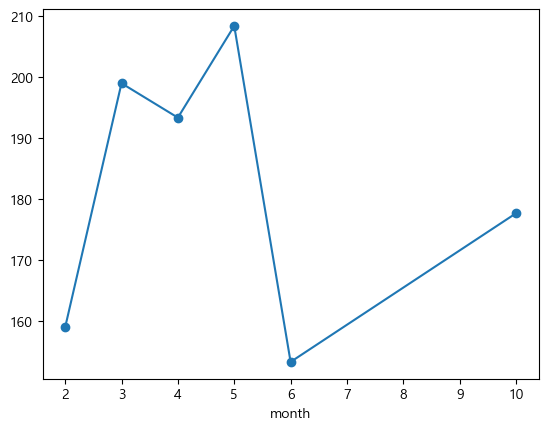

In [74]:
df1.groupby('month')['issueVal'].mean().plot(marker='o')

<Axes: xlabel='month', ylabel='issueVal'>

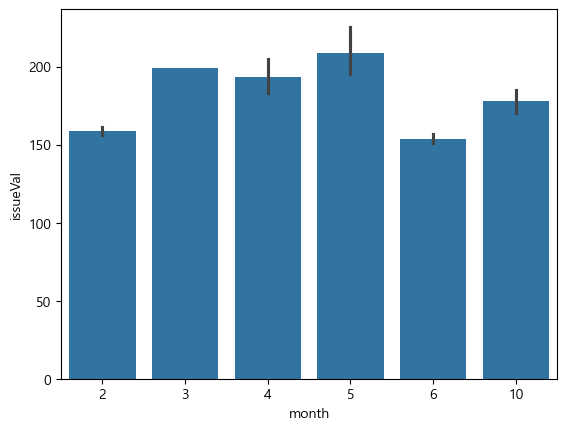

In [75]:
sns.barplot(data=df1, x='month', y='issueVal')

## 6-3. 발령지역(districtName) 분석

In [76]:
df1['districtName'].unique()

array(['전북', '경기', '충남', '광주', '경남', '서울', '제주', '전남', '경북', '부산', '대구',
       '울산', '인천', '강원', '충북', '대전', '세종'], dtype=object)

In [77]:
df1['districtName'].value_counts().head(5)

districtName
전북    41
경기    16
경남    13
인천     7
충남     6
Name: count, dtype: int64

문제) 발령지역 별 발령농도 평균

<Axes: xlabel='districtName'>

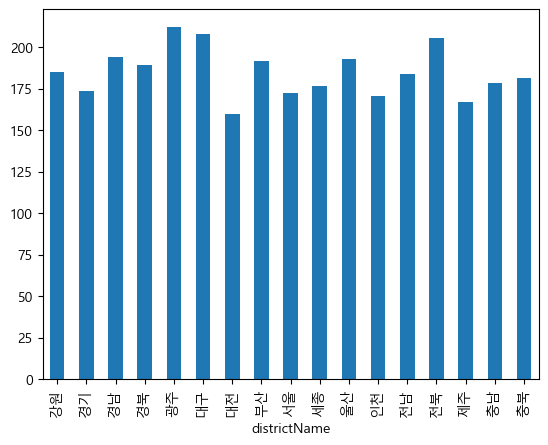

In [78]:
df1.groupby('districtName')['issueVal'].mean().plot(kind='bar')

<Axes: xlabel='districtName', ylabel='issueVal'>

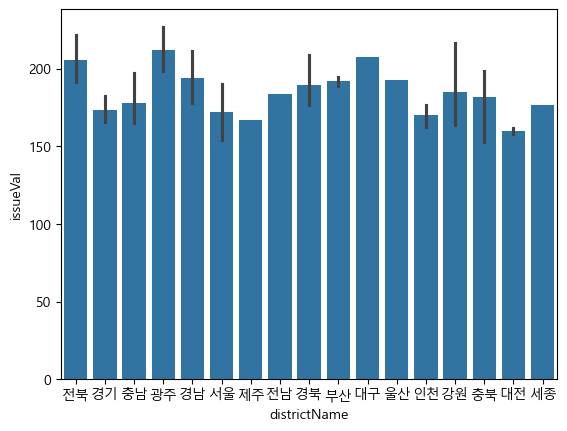

In [79]:
sns.barplot(data=df1, x='districtName', y='issueVal')

## 6-5. 복수 열 기준 groupby — 지역 × 권역

두 개 이상의 열로 그룹화할 때는 리스트로 묶어서 사용합니다:

```python
df.groupby(['열1', '열2'])['집계열'].함수()
```


In [80]:
df1

,clearVal,sn,districtName,dataDate,issueVal,issueTime,clearDate,issueDate,moveName,clearTime,issueGbn,itemCode,year,month,day,clearYear,clearMonth,clearDay
0,56,252,전북,2020-10-22,181,18:00,2020-10-22,2020-10-22,완주권역,20:00,주의보,PM10,2020,10,22,2020,10,22
1,76,248,전북,2020-10-22,179,17:00,2020-10-22,2020-10-22,전주권역,19:00,주의보,PM10,2020,10,22,2020,10,22
2,95,241,경기,2020-10-22,162,16:00,2020-10-22,2020-10-22,남부권,18:00,주의보,PM10,2020,10,22,2020,10,22
3,88,236,경기,2020-10-22,153,14:00,2020-10-22,2020-10-22,북부권,17:00,주의보,PM10,2020,10,22,2020,10,22
4,84,240,충남,2020-10-22,182,15:00,2020-10-22,2020-10-22,북부권역,18:00,주의보,PM10,2020,10,22,2020,10,22
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
103,91,115,충남,2020-02-22,167,10:00,2020-02-22,2020-02-22,서부권역,16:00,주의보,PM10,2020,2,22,2020,2,22
104,95,127,충남,2020-02-22,157,12:00,2020-02-22,2020-02-22,북부권역,16:00,주의보,PM10,2020,2,22,2020,2,22
105,91,123,전북,2020-02-22,159,11:00,2020-02-22,2020-02-22,군산권역,17:00,주의보,PM10,2020,2,22,2020,2,22
106,92,109,서울,2020-02-22,157,10:00,2020-02-22,2020-02-22,서울권역,14:00,주의보,PM10,2020,2,22,2020,2,22


In [81]:
df1[['districtName', 'moveName']]

,districtName,moveName
0,전북,완주권역
1,전북,전주권역
2,경기,남부권
3,경기,북부권
4,충남,북부권역
...,...,...
103,충남,서부권역
104,충남,북부권역
105,전북,군산권역
106,서울,서울권역


문제) 발령지역 × 발령권역별 발령농도 평균

In [82]:
result = df1.groupby(['districtName', 'moveName'])['issueVal'].mean().sort_values(ascending=False).head(10)
result

districtName  moveName
전북            임실권역       298.8
              순창권역       242.3
경남            함안권역       226.0
              밀양권역       221.0
전북            완주권역       216.7
광주            광주권역       212.3
경북            서부권역       209.0
대구            대구권역       208.0
전북            부안권역       203.5
              전주권역       199.2
Name: issueVal, dtype: float64

<Axes: ylabel='districtName,moveName'>

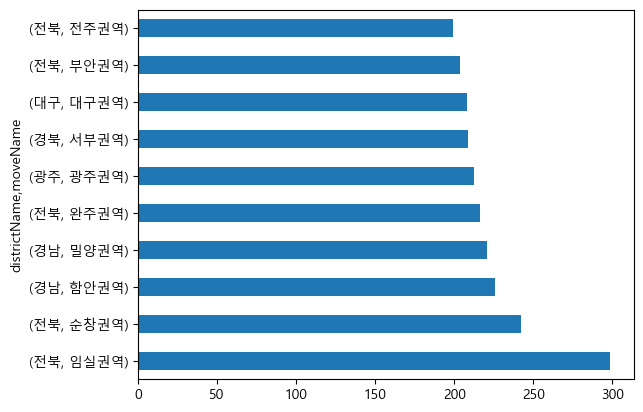

In [83]:
result.plot(kind='barh')

문제) 발령지역별 발령농도 vs 해제농도 평균

In [84]:
df1.groupby('districtName')[ ['issueVal','clearVal']].mean()

,issueVal,clearVal
districtName,,
강원,185.3,90.3
경기,173.8,85.8
경남,194.2,81.6
경북,189.7,75.0
광주,212.3,63.0
대구,208.0,76.0
대전,160.0,84.0
부산,192.0,90.0
서울,172.2,92.8


<Axes: xlabel='districtName'>

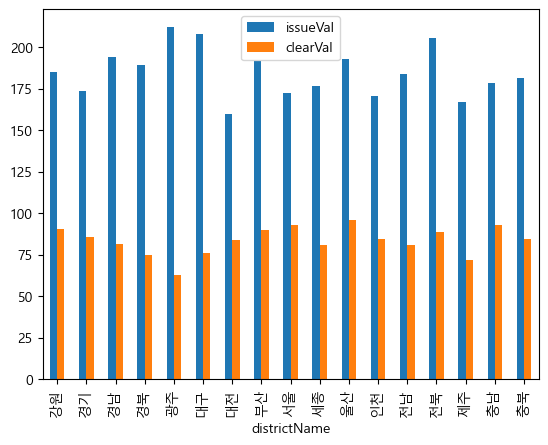

In [85]:
df1.groupby('districtName')[ ['issueVal','clearVal']].mean().plot.bar()

In [86]:
df1.groupby('districtName')[ ['issueVal','clearVal']].mean().reset_index()

,districtName,issueVal,clearVal
0,강원,185.3,90.3
1,경기,173.8,85.8
2,경남,194.2,81.6
3,경북,189.7,75.0
4,광주,212.3,63.0
5,대구,208.0,76.0
6,대전,160.0,84.0
7,부산,192.0,90.0
8,서울,172.2,92.8
9,세종,177.0,81.0



---
# PART 7 — 최대값·최소값 탐색
---


### 최대값·최소값 찾기 — `max()`, `min()`, `idxmax()`, `idxmin()`

| 함수 | 반환값 | 설명 |
|------|--------|------|
| `df['열'].max()` | 값 | 최대값 |
| `df['열'].min()` | 값 | 최소값 |
| `df['열'].idxmax()` | **인덱스** | 최대값을 가진 행의 인덱스 |
| `df['열'].idxmin()` | **인덱스** | 최소값을 가진 행의 인덱스 |

발령농도 최대값

In [87]:
print(df1['issueVal'].max())

380


최대값의 인덱스 번호 찾기

In [88]:
df1['issueVal'].idxmax()

32

최대값을 가진 행 (가장 높은 발령농도 데이터) 전체 출력

In [89]:
df1.loc[df1['issueVal'].idxmax()]

clearVal                        111
sn                              213
districtName                     전북
dataDate                 2020-05-14
issueVal                        380
issueTime                     17:00
clearDate       2020-05-14 00:00:00
issueDate       2020-05-14 00:00:00
moveName                       임실권역
clearTime                     22:00
issueGbn                         경보
itemCode                       PM10
year                           2020
month                             5
day                              14
clearYear                      2020
clearMonth                        5
clearDay                         14
Name: 32, dtype: object

발령농도 최소값

In [97]:
print(df1['issueVal'].min())

150


최소값의 인덱스 번호 찾기

In [98]:
df1['issueVal'].idxmin()

81

최소값을 가진 행 (가장 낮은 발령농도 데이터) 전체 출력

In [99]:
df1.loc[df1['issueVal'].idxmin()]

clearVal                         74
sn                              166
districtName                     경남
dataDate                 2020-04-04
issueVal                        150
issueTime                     17:00
clearDate       2020-04-04 00:00:00
issueDate       2020-04-04 00:00:00
moveName                       함양권역
clearTime                     19:00
issueGbn                        주의보
itemCode                       PM10
year                           2020
month                             4
day                               4
clearYear                      2020
clearMonth                        4
clearDay                          4
Name: 81, dtype: object


---
# PART 8 — agg() 다중 집계 & 시각화
---


## `agg()` — 여러 집계 함수 한번에 적용

```python
df.groupby('기준열')['집계열'].agg(['mean', 'max', 'min'])
```

- **하나의 groupby() ** 로 평균·최대·최소등을 **동시에** 구할 수 있어요!
- 결과가 **DataFrame** 으로 반환됩니다 → 바로 시각화 가능!


월별 발령농도 — 평균·최대·최소 동시 집계

In [90]:
df1.groupby('month')['issueVal'].agg([  'mean', 'max', 'min' ])

,mean,max,min
month,,,
2,159.0,167,151
3,199.0,199,199
4,193.4,282,150
5,208.4,380,156
6,153.3,157,151
10,177.7,218,151


<Axes: xlabel='month'>

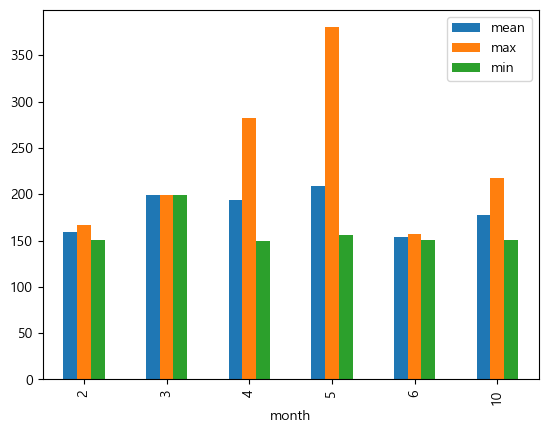

In [91]:
df1.groupby('month')['issueVal'].agg([  'mean', 'max', 'min' ]).plot(kind="bar")

In [92]:
df

,clearVal,sn,districtName,dataDate,issueVal,issueTime,clearDate,issueDate,moveName,clearTime,issueGbn,itemCode,year,month,day,clearYear,clearMonth,clearDay
0,33,323,충북,2020-12-29,77,13:00,2020-12-29,2020-12-29,중부권역,19:00,주의보,PM25,2020,12,29,2020,12,29
1,33,322,세종,2020-12-29,80,12:00,2020-12-29,2020-12-29,세종권역,19:00,주의보,PM25,2020,12,29,2020,12,29
2,34,320,대구,2020-12-28,83,14:00,2020-12-28,2020-12-28,대구권역,16:00,주의보,PM25,2020,12,28,2020,12,28
3,28,321,충남,2020-12-28,76,21:00,2020-12-29,2020-12-28,북부권역,22:00,주의보,PM25,2020,12,28,2020,12,29
4,26,318,대구,2020-12-24,80,11:00,2020-12-24,2020-12-24,대구권역,15:00,주의보,PM25,2020,12,24,2020,12,24
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
299,33,4,충북,2020-01-03,76,12:00,2020-01-05,2020-01-03,중부권역,16:00,주의보,PM25,2020,1,3,2020,1,5
300,31,3,충남,2020-01-03,85,11:00,2020-01-05,2020-01-03,북부권역,15:00,주의보,PM25,2020,1,3,2020,1,5
301,19,1,전북,2020-01-03,80,02:00,2020-01-05,2020-01-03,익산권역,15:00,주의보,PM25,2020,1,3,2020,1,5
302,33,2,경기,2020-01-03,82,11:00,2020-01-04,2020-01-03,남부권,17:00,주의보,PM25,2020,1,3,2020,1,4


앞에서 한 분석은 PM10(미세먼지) 기준이었어요.     
이번에는 PM25(초미세먼지) 만 필터링해서 다음 과제를 풀어보세요

In [93]:
df

,clearVal,sn,districtName,dataDate,issueVal,issueTime,clearDate,issueDate,moveName,clearTime,issueGbn,itemCode,year,month,day,clearYear,clearMonth,clearDay
0,33,323,충북,2020-12-29,77,13:00,2020-12-29,2020-12-29,중부권역,19:00,주의보,PM25,2020,12,29,2020,12,29
1,33,322,세종,2020-12-29,80,12:00,2020-12-29,2020-12-29,세종권역,19:00,주의보,PM25,2020,12,29,2020,12,29
2,34,320,대구,2020-12-28,83,14:00,2020-12-28,2020-12-28,대구권역,16:00,주의보,PM25,2020,12,28,2020,12,28
3,28,321,충남,2020-12-28,76,21:00,2020-12-29,2020-12-28,북부권역,22:00,주의보,PM25,2020,12,28,2020,12,29
4,26,318,대구,2020-12-24,80,11:00,2020-12-24,2020-12-24,대구권역,15:00,주의보,PM25,2020,12,24,2020,12,24
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
299,33,4,충북,2020-01-03,76,12:00,2020-01-05,2020-01-03,중부권역,16:00,주의보,PM25,2020,1,3,2020,1,5
300,31,3,충남,2020-01-03,85,11:00,2020-01-05,2020-01-03,북부권역,15:00,주의보,PM25,2020,1,3,2020,1,5
301,19,1,전북,2020-01-03,80,02:00,2020-01-05,2020-01-03,익산권역,15:00,주의보,PM25,2020,1,3,2020,1,5
302,33,2,경기,2020-01-03,82,11:00,2020-01-04,2020-01-03,남부권,17:00,주의보,PM25,2020,1,3,2020,1,4


In [94]:
df1

,clearVal,sn,districtName,dataDate,issueVal,issueTime,clearDate,issueDate,moveName,clearTime,issueGbn,itemCode,year,month,day,clearYear,clearMonth,clearDay
0,56,252,전북,2020-10-22,181,18:00,2020-10-22,2020-10-22,완주권역,20:00,주의보,PM10,2020,10,22,2020,10,22
1,76,248,전북,2020-10-22,179,17:00,2020-10-22,2020-10-22,전주권역,19:00,주의보,PM10,2020,10,22,2020,10,22
2,95,241,경기,2020-10-22,162,16:00,2020-10-22,2020-10-22,남부권,18:00,주의보,PM10,2020,10,22,2020,10,22
3,88,236,경기,2020-10-22,153,14:00,2020-10-22,2020-10-22,북부권,17:00,주의보,PM10,2020,10,22,2020,10,22
4,84,240,충남,2020-10-22,182,15:00,2020-10-22,2020-10-22,북부권역,18:00,주의보,PM10,2020,10,22,2020,10,22
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
103,91,115,충남,2020-02-22,167,10:00,2020-02-22,2020-02-22,서부권역,16:00,주의보,PM10,2020,2,22,2020,2,22
104,95,127,충남,2020-02-22,157,12:00,2020-02-22,2020-02-22,북부권역,16:00,주의보,PM10,2020,2,22,2020,2,22
105,91,123,전북,2020-02-22,159,11:00,2020-02-22,2020-02-22,군산권역,17:00,주의보,PM10,2020,2,22,2020,2,22
106,92,109,서울,2020-02-22,157,10:00,2020-02-22,2020-02-22,서울권역,14:00,주의보,PM10,2020,2,22,2020,2,22


In [95]:
df2 = df[df['itemCode'] =='PM25']
df2

,clearVal,sn,districtName,dataDate,issueVal,issueTime,clearDate,issueDate,moveName,clearTime,issueGbn,itemCode,year,month,day,clearYear,clearMonth,clearDay
0,33,323,충북,2020-12-29,77,13:00,2020-12-29,2020-12-29,중부권역,19:00,주의보,PM25,2020,12,29,2020,12,29
1,33,322,세종,2020-12-29,80,12:00,2020-12-29,2020-12-29,세종권역,19:00,주의보,PM25,2020,12,29,2020,12,29
2,34,320,대구,2020-12-28,83,14:00,2020-12-28,2020-12-28,대구권역,16:00,주의보,PM25,2020,12,28,2020,12,28
3,28,321,충남,2020-12-28,76,21:00,2020-12-29,2020-12-28,북부권역,22:00,주의보,PM25,2020,12,28,2020,12,29
4,26,318,대구,2020-12-24,80,11:00,2020-12-24,2020-12-24,대구권역,15:00,주의보,PM25,2020,12,24,2020,12,24
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
299,33,4,충북,2020-01-03,76,12:00,2020-01-05,2020-01-03,중부권역,16:00,주의보,PM25,2020,1,3,2020,1,5
300,31,3,충남,2020-01-03,85,11:00,2020-01-05,2020-01-03,북부권역,15:00,주의보,PM25,2020,1,3,2020,1,5
301,19,1,전북,2020-01-03,80,02:00,2020-01-05,2020-01-03,익산권역,15:00,주의보,PM25,2020,1,3,2020,1,5
302,33,2,경기,2020-01-03,82,11:00,2020-01-04,2020-01-03,남부권,17:00,주의보,PM25,2020,1,3,2020,1,4


In [96]:
df2 = df2.reset_index(drop=True)
df2

,clearVal,sn,districtName,dataDate,issueVal,issueTime,clearDate,issueDate,moveName,clearTime,issueGbn,itemCode,year,month,day,clearYear,clearMonth,clearDay
0,33,323,충북,2020-12-29,77,13:00,2020-12-29,2020-12-29,중부권역,19:00,주의보,PM25,2020,12,29,2020,12,29
1,33,322,세종,2020-12-29,80,12:00,2020-12-29,2020-12-29,세종권역,19:00,주의보,PM25,2020,12,29,2020,12,29
2,34,320,대구,2020-12-28,83,14:00,2020-12-28,2020-12-28,대구권역,16:00,주의보,PM25,2020,12,28,2020,12,28
3,28,321,충남,2020-12-28,76,21:00,2020-12-29,2020-12-28,북부권역,22:00,주의보,PM25,2020,12,28,2020,12,29
4,26,318,대구,2020-12-24,80,11:00,2020-12-24,2020-12-24,대구권역,15:00,주의보,PM25,2020,12,24,2020,12,24
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
191,33,4,충북,2020-01-03,76,12:00,2020-01-05,2020-01-03,중부권역,16:00,주의보,PM25,2020,1,3,2020,1,5
192,31,3,충남,2020-01-03,85,11:00,2020-01-05,2020-01-03,북부권역,15:00,주의보,PM25,2020,1,3,2020,1,5
193,19,1,전북,2020-01-03,80,02:00,2020-01-05,2020-01-03,익산권역,15:00,주의보,PM25,2020,1,3,2020,1,5
194,33,2,경기,2020-01-03,82,11:00,2020-01-04,2020-01-03,남부권,17:00,주의보,PM25,2020,1,3,2020,1,4


#### 과제 1: 월별 초미세먼지 평균 발령농도는? 

In [100]:
df2

,clearVal,sn,districtName,dataDate,issueVal,issueTime,clearDate,issueDate,moveName,clearTime,issueGbn,itemCode,year,month,day,clearYear,clearMonth,clearDay
0,33,323,충북,2020-12-29,77,13:00,2020-12-29,2020-12-29,중부권역,19:00,주의보,PM25,2020,12,29,2020,12,29
1,33,322,세종,2020-12-29,80,12:00,2020-12-29,2020-12-29,세종권역,19:00,주의보,PM25,2020,12,29,2020,12,29
2,34,320,대구,2020-12-28,83,14:00,2020-12-28,2020-12-28,대구권역,16:00,주의보,PM25,2020,12,28,2020,12,28
3,28,321,충남,2020-12-28,76,21:00,2020-12-29,2020-12-28,북부권역,22:00,주의보,PM25,2020,12,28,2020,12,29
4,26,318,대구,2020-12-24,80,11:00,2020-12-24,2020-12-24,대구권역,15:00,주의보,PM25,2020,12,24,2020,12,24
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
191,33,4,충북,2020-01-03,76,12:00,2020-01-05,2020-01-03,중부권역,16:00,주의보,PM25,2020,1,3,2020,1,5
192,31,3,충남,2020-01-03,85,11:00,2020-01-05,2020-01-03,북부권역,15:00,주의보,PM25,2020,1,3,2020,1,5
193,19,1,전북,2020-01-03,80,02:00,2020-01-05,2020-01-03,익산권역,15:00,주의보,PM25,2020,1,3,2020,1,5
194,33,2,경기,2020-01-03,82,11:00,2020-01-04,2020-01-03,남부권,17:00,주의보,PM25,2020,1,3,2020,1,4


In [102]:
pm25_df = df[df['itemCode'] == 'PM25'].copy()

pm25_df['issueVal'] = pd.to_numeric(pm25_df['issueVal'])
pm25_df['issueDate'] = pd.to_datetime(pm25_df['issueDate'])

pm25_df['month'] = pm25_df['issueDate'].dt.month

monthly_avg = pm25_df.groupby('month')['issueVal'].mean().round(1).reset_index()
monthly_avg.columns = ['월', '평균발령농도']
print(monthly_avg)

    월  평균발령농도
0   1    85.7
1   2    81.6
2   3    85.2
3   5    79.0
4   6    85.2
5   8    85.0
6  10    78.5
7  11    81.7
8  12    80.2


#### 과제 2: 초미세먼지 발령농도가 가장 높은 상위 10개 지역(distrctName)과 발령일시, 발령농도를 구하시오.

In [103]:
pm25_df['발령일시'] = pm25_df['issueDate'].dt.strftime('%Y-%m-%d') + " " + pm25_df['issueTime']

top10_pm25 = pm25_df.sort_values(by='issueVal', ascending=False).head(10)

result_top10 = top10_pm25[['districtName', '발령일시', 'issueVal']].reset_index(drop=True)
result_top10.columns = ['지역(districtName)', '발령일시', '발령농도']

print(result_top10)

  지역(districtName)              발령일시  발령농도
0               전북  2020-03-09 20:00   119
1               전북  2020-02-14 21:00   110
2               전북  2020-06-08 22:00   106
3               전북  2020-01-19 17:00   105
4               전북  2020-02-10 13:00   104
5               전북  2020-01-24 11:00   104
6               충남  2020-01-19 15:00   103
7               전북  2020-01-19 16:00   101
8               전북  2020-01-19 16:00    98
9               전북  2020-12-11 20:00    96


여러분 어떻게 공부하셨나요?   
공공데이터 포털에서 미세먼지경보현황관련 OPEN API를 통해 직접 데이터를 수집해 분석해보았습니다    
사실 가장 중요한 부분이 양질의 데이터를 확보하는 것이고        
그것이 바로 현재 AI 기술 발전의 기본이 되고 있는 것입니다    
여러분은 **어떠한 데이터에 관심**이 있으신가요?         
이제 **데이터를 찾아보는 노력**을 시작해보세요!!     
그것으로부터 **프로젝트를 시작할 준비**를 할 수 있게 됩니다   
공부하면서 어떠한 일이 있었는 지 **아래 셀에 꼭 적어서** 저와 공유해주세요!!    

In [ ]:
중간에 변수 선언을 건너뛰어 발생한 사소한 오류를 겪었고, 저는 금융데이터에 관심이 많습니다.